# Customer Churn Prediction using an Artificial Neural Network (ANN)

This notebook builds a complete deep learning pipeline to predict customer churn for a telecom company using the Telco Customer Churn dataset. We use TensorFlow/Keras to build the ANN and Scikit-Learn for preprocessing and evaluation.

## Part 1 — Data Exploration

We start by importing the required libraries, fixing random seeds for reproducibility, loading the dataset, and inspecting its structure, data types, missing values, and the target class distribution.

In [3]:
# Core libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set a global random seed for reproducibility across numpy, tensorflow, and python's random module
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preview the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Structural information: column names, dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Summary statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Count missing values per column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


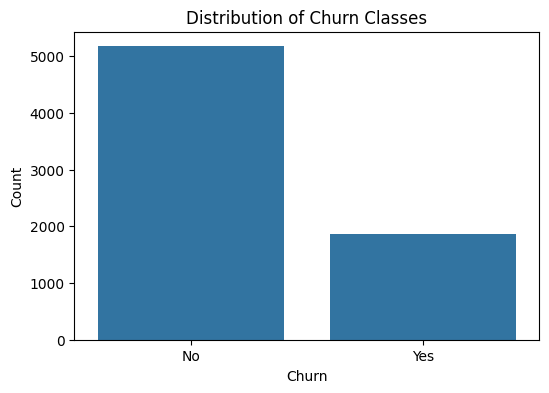

In [11]:
# Class distribution of the target variable (Churn)
churn_counts = df["Churn"].value_counts()
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:\n", churn_counts)
print("\nChurn percentage:\n", churn_percentage)

# Bar plot of the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, order=["No", "Yes"])
plt.title("Distribution of Churn Classes")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## Part 2 — Data Preprocessing

Before feeding data into a neural network, we must clean and numerically encode it:
- Fix the `TotalCharges` column, which contains blank strings for customers with `tenure = 0`.
- Drop the identifier column `customerID`, which carries no predictive signal.
- Encode the target variable and categorical features into numeric form.
- Split the data into train/test sets and scale continuous numeric features.

In [12]:
# TotalCharges is stored as an object dtype because some rows have blank strings
# (these correspond to customers with tenure == 0, i.e. brand new customers).
# Coerce to numeric, turning blanks into NaN, then impute with the median.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Confirm there are no missing values left
df["TotalCharges"].isnull().sum()

np.int64(0)

In [13]:
# customerID is a unique identifier with no predictive value; drop it
df = df.drop(columns=["customerID"])

# Map the target column Churn: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [14]:
# Label-encode binary categorical columns (each has exactly two categories)
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

label_encoder = LabelEncoder()
for col in binary_cols:
    df[col] = label_encoder.fit_transform(df[col])

df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [15]:
# One-hot encode multi-class categorical columns
multi_class_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)

# Ensure one-hot encoded columns are integer (0/1) rather than boolean
df = df.astype({col: "int" for col in df.columns if df[col].dtype == "bool"})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [16]:
# Split into features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (7043, 30)
Target vector shape: (7043,)


In [17]:
# Train/test split: 80% train, 20% test, stratified by y to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)


In [18]:
# Scale continuous numeric columns using StandardScaler.
# The scaler is fit ONLY on the training data to avoid data leakage from the test set.
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train[continuous_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,-3.783508e-18
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.002135e+00
25%,-9.559779e-01,-9.711977e-01,-8.309023e-01
50%,-1.418632e-01,1.848336e-01,-3.968393e-01
75%,9.164859e-01,8.319124e-01,6.737360e-01
max,1.608483e+00,1.785939e+00,2.802714e+00


## Part 3 — ANN Architecture (Keras Sequential)

We build a fully connected feed-forward neural network using Keras's `Sequential` API:
- An input layer sized to the number of processed features.
- Two hidden layers with ReLU activation to learn non-linear patterns.
- A single sigmoid output neuron for binary classification (churn / no churn).

In [19]:
n_features = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Part 4 — Compilation

We compile the model with the Adam optimizer and binary cross-entropy loss, since this is a binary classification problem. Accuracy is tracked as the evaluation metric.

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## Part 5 — Training

We train the model for 50 epochs with a batch size of 32, holding out 20% of the training data for validation so we can monitor overfitting during training.

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7772 - loss: 0.4714 - val_accuracy: 0.7853 - val_loss: 0.4500
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7994 - loss: 0.4241 - val_accuracy: 0.7782 - val_loss: 0.4443
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8012 - loss: 0.4161 - val_accuracy: 0.7799 - val_loss: 0.4430
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8036 - loss: 0.4117 - val_accuracy: 0.7764 - val_loss: 0.4424
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8076 - loss: 0.4088 - val_accuracy: 0.7808 - val_loss: 0.4425
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8065 - loss: 0.4066 - val_accuracy: 0.7817 - val_loss: 0.4431
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8076 - loss: 0.4048 - val_accuracy: 0.7808 - val_loss: 0.4431
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - loss: 0.4030 - val_accuracy: 0.

## Part 6 — Evaluation

We evaluate the trained model on the held-out test set and inspect its predictive performance using a confusion matrix and a full classification report (precision, recall, F1-score).

In [22]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7708 - loss: 0.4567
Test Loss: 0.4567
Test Accuracy: 0.7708


In [23]:
# Generate predicted probabilities and convert to class labels using a 0.5 threshold
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


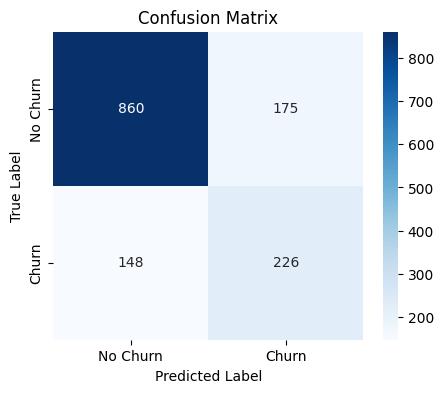

In [24]:
# Confusion matrix as a labeled heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [25]:
# Full classification report: precision, recall, f1-score per class
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



## Part 7 — Visualization

We plot training vs. validation accuracy and loss across all 50 epochs to visually inspect the model's learning curve and check for overfitting or underfitting.

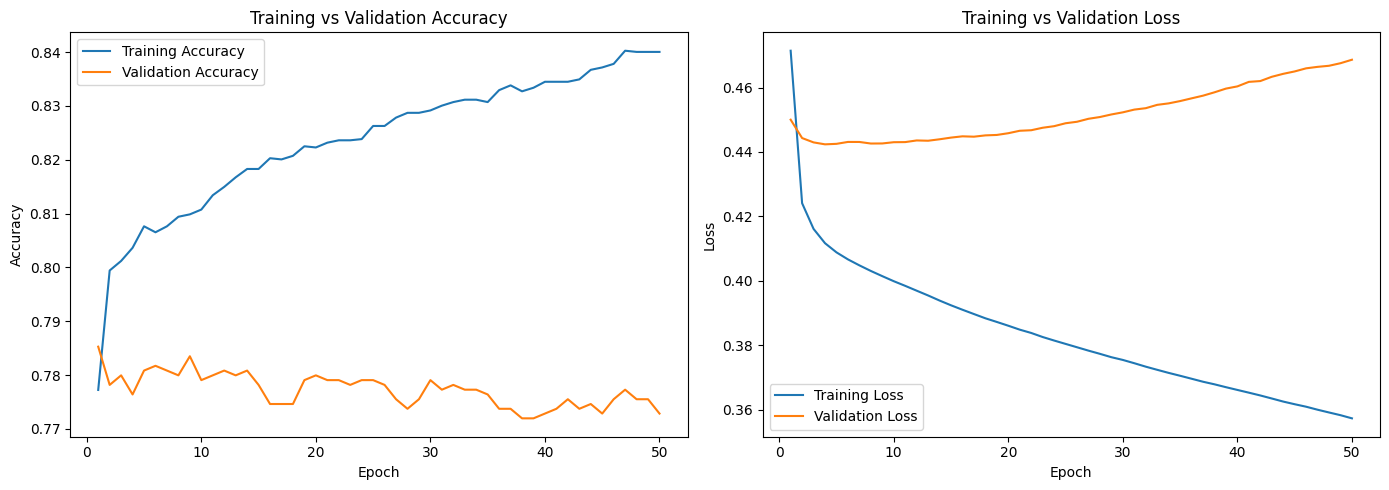

In [26]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy subplot
axes[0].plot(epochs_range, history.history["accuracy"], label="Training Accuracy")
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss subplot
axes[1].plot(epochs_range, history.history["loss"], label="Training Loss")
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 8 — Final Predictions Comparison

As a sanity check, we compare the actual churn labels against the model's predicted labels for the first 20 samples in the test set.

In [27]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20],
})

comparison_df

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,1
7,0,0
8,0,0
9,1,0


## Final Steps — Save the Trained Model

We persist the trained ANN to disk in the native Keras format so it can be reloaded later without retraining.

In [30]:
model.save("churn_model.keras")
print("Model saved as churn_model.keras")

Model saved as churn_model.keras
